### Data Inspection

In [6]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import preparations as prep # dataset loading and definitions
import helper as hlp # helper functions for plotting and image processing
import importlib
importlib.reload(hlp)
importlib.reload(prep)

<module 'preparations' from '/Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/notebooks/preparations.py'>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [8]:
# Download the dataset (take from cache if already downloaded)
prep.download_and_move_dataset()

# Show the root dir content of the dataset
parent_folder = os.path.dirname(os.getcwd())
folder_path = os.path.join(parent_folder, prep.COVID_FOLDER)
print(folder_path)
files = os.listdir(folder_path)  # List all files and folders
print(files)

Dataset not found. Downloading...


100%|██████████| 778M/778M [02:29<00:00, 5.44MB/s] 

Extracting files...


Covid-19 Radiography Dataset downloaded and moved to parent directory.
/Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/COVID-19_Radiography_Dataset
['Lung_Opacity.metadata.xlsx', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID.metadata.xlsx', 'Normal.metadata.xlsx', 'Lung_Opacity', 'Normal', 'COVID', 'README.md.txt']


##### Data Content

> The data in the 'COVID-19_Radiography_Dataset' from kaggle is composed of several classes. Inspect the proportions of those classes.

In [9]:
# The folder where the images are stored
parent_folder = os.path.dirname(os.getcwd())
folder_path = os.path.join(parent_folder, prep.COVID_FOLDER)
print(folder_path)
files = os.listdir(folder_path)  # List all files and folders
print(files)

/Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/COVID-19_Radiography_Dataset
['Lung_Opacity.metadata.xlsx', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID.metadata.xlsx', 'Normal.metadata.xlsx', 'Lung_Opacity', 'Normal', 'COVID', 'README.md.txt']


In [10]:
# We read in all file names of the data set into dictionaries

folder_covid = os.path.join(folder_path, 'COVID')
folder_normal = os.path.join(folder_path, 'Normal')
folder_lung_opacity = os.path.join(folder_path, 'Lung_Opacity')
folder_viral_pneumonia = os.path.join(folder_path, 'Viral Pneumonia')

sub_image = 'images'
sub_mask = 'masks'

# This definition, we will need often
image_classes = ['covid', 'lung_opacity', 'viral_pneumonia', 'normal']

folder_dict = {image_classes[0]: folder_covid, 
               image_classes[1]: folder_lung_opacity, 
               image_classes[2]: folder_viral_pneumonia, 
               image_classes[3]: folder_normal}

images_files_dict = {}
masks_files_dict = {}

for key, folder in folder_dict.items():
    print('Reading file_names of class:', key)
    images_files_dict[key] = np.sort(os.listdir(os.path.join(folder, sub_image)))
    masks_files_dict[key] = np.sort(os.listdir(os.path.join(folder, sub_mask)))

print('Images:', images_files_dict)
print('Masks:', masks_files_dict)

Reading file_names of class: covid
Reading file_names of class: lung_opacity
Reading file_names of class: viral_pneumonia
Reading file_names of class: normal
Images: {'covid': array(['COVID-1.png', 'COVID-10.png', 'COVID-100.png', ...,
       'COVID-997.png', 'COVID-998.png', 'COVID-999.png'], dtype='<U14'), 'lung_opacity': array(['Lung_Opacity-1.png', 'Lung_Opacity-10.png',
       'Lung_Opacity-100.png', ..., 'Lung_Opacity-997.png',
       'Lung_Opacity-998.png', 'Lung_Opacity-999.png'], dtype='<U21'), 'viral_pneumonia': array(['Viral Pneumonia-1.png', 'Viral Pneumonia-10.png',
       'Viral Pneumonia-100.png', ..., 'Viral Pneumonia-997.png',
       'Viral Pneumonia-998.png', 'Viral Pneumonia-999.png'], dtype='<U24'), 'normal': array(['Normal-1.png', 'Normal-10.png', 'Normal-100.png', ...,
       'Normal-9997.png', 'Normal-9998.png', 'Normal-9999.png'],
      dtype='<U16')}
Masks: {'covid': array(['COVID-1.png', 'COVID-10.png', 'COVID-100.png', ...,
       'COVID-997.png', 'COVID-998.

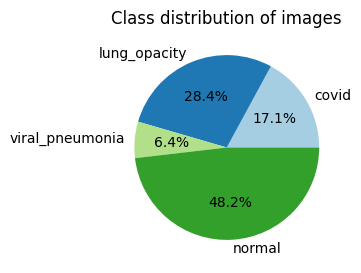

In [11]:
# Show the distribution of classes
plt.figure(figsize=(3,3))
plt.pie([len(value) for value in images_files_dict.values()], labels=images_files_dict.keys(), colors=plt.cm.Paired.colors, autopct='%1.1f%%')
plt.title('Class distribution of images')
plt.show()

##### Data Origin

> The data in the 'COVID-19_Radiography_Dataset' from kaggle is composed of several origins. We can evaluate, if we identify differences in data quality

##### reusable functions

In [12]:
def create_origin_dictionary(metadata, adapt_file_name=False):
    file_dict = {}
    for url in metadata.URL.unique():
        file_list = metadata[metadata.URL == url].reset_index(drop=True)
        if adapt_file_name == False:
            file_dict[url] = [row['FILE NAME'] + '.' + row['FORMAT'].lower() for _, row in file_list.iterrows()]
        else:
            file_dict[url] = [row['FILE NAME'].lower().capitalize() + '.' + row['FORMAT'].lower() for _, row in file_list.iterrows()]
    return file_dict

In [13]:
def make_img_file_path(img_name, folder, mask=False):
    if (mask):
        return os.path.join(folder, sub_mask, img_name)
    else:
        return os.path.join(folder, sub_image, img_name)

In [14]:
def show_sample_images(origin_dictionary, image_path):
    for url, file_names in origin_dictionary.items():
        print('URL:', url)
        random_files = np.random.choice(file_names, 9)
        random_file_names = [make_img_file_path(file_name, image_path) for file_name in random_files]    

        plt.figure(figsize=(12,14))
        i = 1
        for file_name,file_path in zip(random_files,random_file_names):
            plt.subplot(3,3,i)
            plt.imshow(plt.imread(file_path), cmap='gray')
            plt.xticks([])
            plt.yticks([])
            plt.title(file_name)
            i += 1
        plt.show()

##### Evaluate 'normal' images (show some examples of each origin)

In [15]:
excel_path_normal = os.path.join(folder_path,'Normal.metadata.xlsx')
print(excel_path_normal)
df_normal = pd.read_excel(excel_path_normal)
df_normal.head()

/Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/COVID-19_Radiography_Dataset/Normal.metadata.xlsx


,FILE NAME,FORMAT,SIZE,URL
0,NORMAL-1,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
1,NORMAL-2,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
2,NORMAL-3,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
3,NORMAL-4,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
4,NORMAL-5,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...


In [16]:
df_normal.URL.value_counts()

URL
https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/data    8851
https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia       1341
Name: count, dtype: int64

In [17]:
origin_dictionary_normal = create_origin_dictionary(df_normal, adapt_file_name=True)
for url, file_names in origin_dictionary_normal.items():
    print('first file from URL:', url, file_names[0])

first file from URL: https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/data Normal-1.png
first file from URL: https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia Normal-8852.png


URL: https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/data


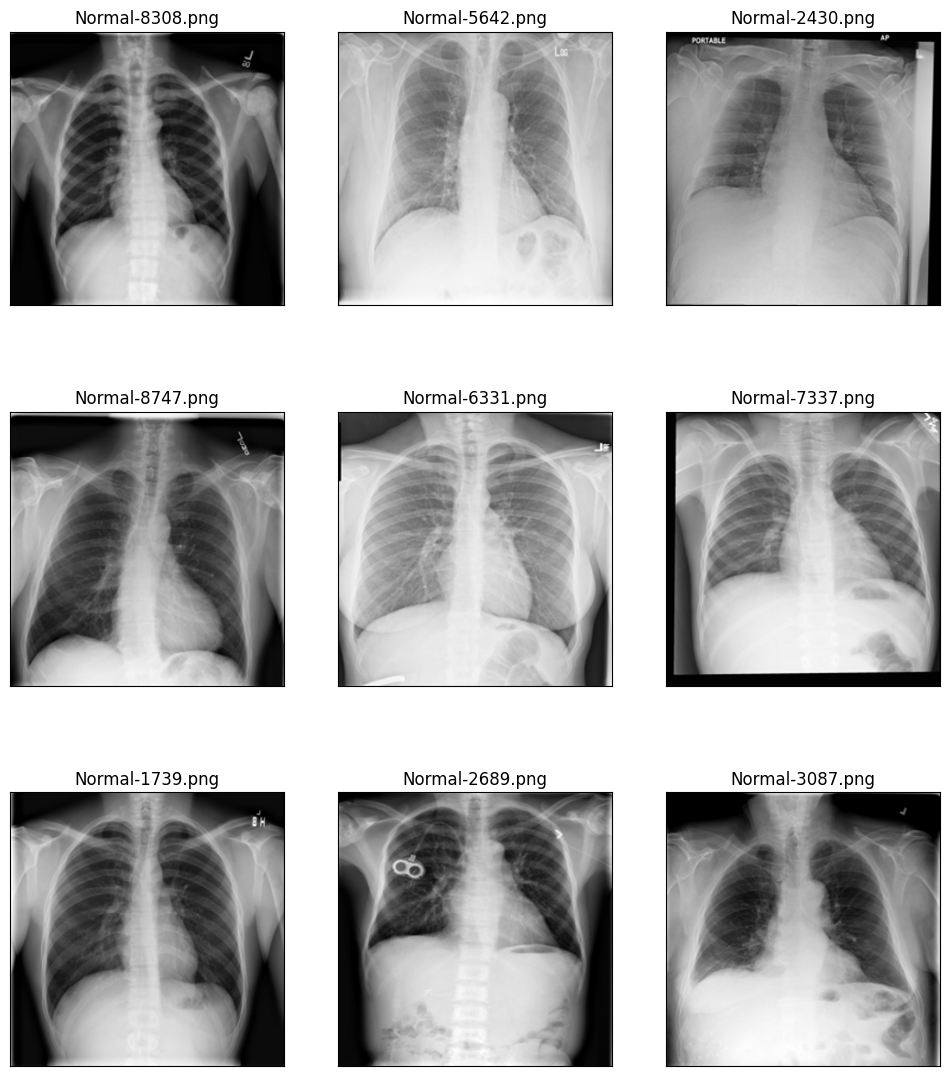

URL: https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia


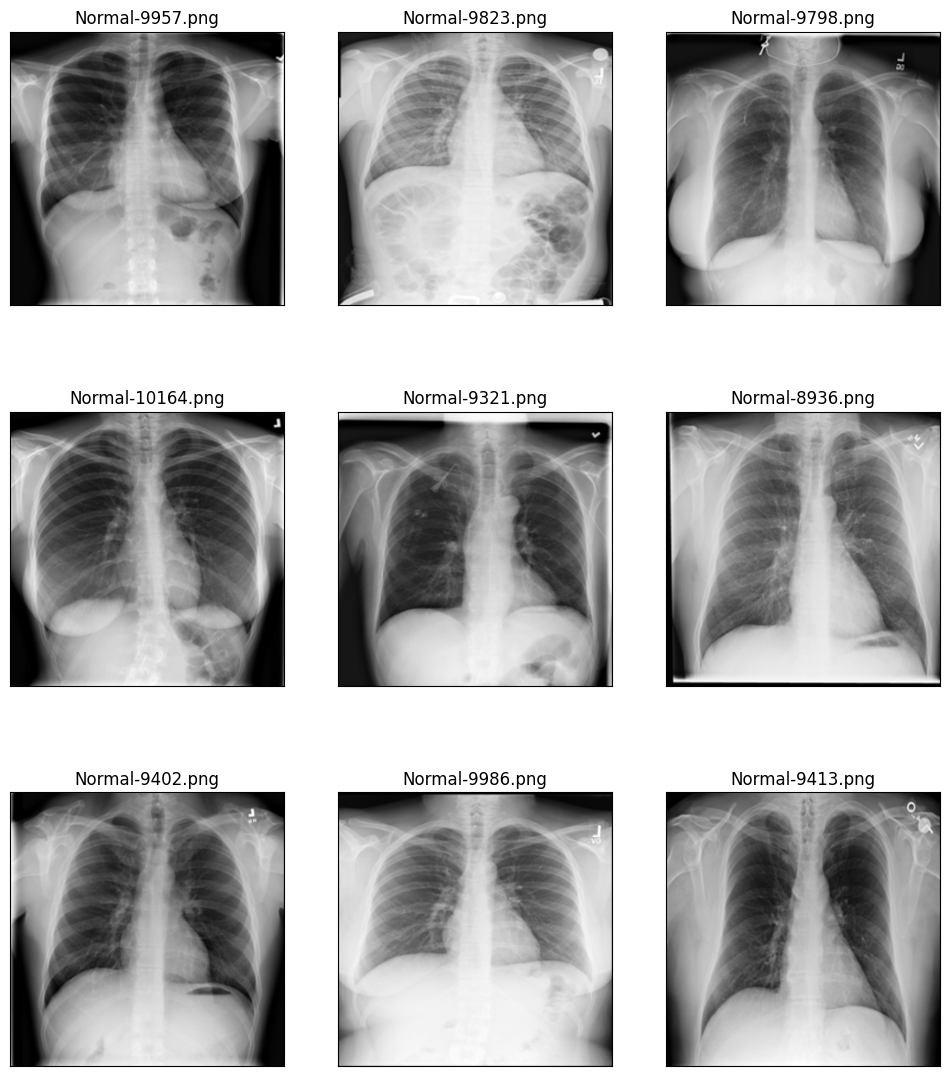

In [18]:
show_sample_images(origin_dictionary_normal, folder_normal)

##### Evaluate 'covid' images (show some examples of each origin)

In [19]:
excel_path_covid = os.path.join(folder_path,'COVID.metadata.xlsx')
print(excel_path_covid)
df_covid = pd.read_excel(excel_path_covid)
df_covid.head()

/Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/COVID-19_Radiography_Dataset/COVID.metadata.xlsx


,FILE NAME,FORMAT,SIZE,URL
0,COVID-1,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
1,COVID-2,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
2,COVID-3,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
3,COVID-4,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
4,COVID-5,PNG,256*256,https://sirm.org/category/senza-categoria/covi...


In [20]:
df_covid.URL.value_counts()

URL
https://bimcv.cipf.es/bimcv-projects/bimcv-covid19/#1590858128006-9e640421-6711    2474
https://github.com/armiro/COVID-CXNet                                               400
https://eurorad.org                                                                 258
https://github.com/ml-workgroup/covid-19-image-repository/tree/master/png           183
https://github.com/ieee8023/covid-chestxray-dataset                                 182
https://sirm.org/category/senza-categoria/covid-19/                                 119
Name: count, dtype: int64

In [21]:
origin_dictionary_covid = create_origin_dictionary(df_covid)
for url, file_names in origin_dictionary_covid.items():
    print('first file from URL:', url, file_names[0])

first file from URL: https://sirm.org/category/senza-categoria/covid-19/ COVID-1.png
first file from URL: https://github.com/ml-workgroup/covid-19-image-repository/tree/master/png COVID-120.png
first file from URL: https://eurorad.org COVID-303.png
first file from URL: https://github.com/armiro/COVID-CXNet COVID-561.png
first file from URL: https://github.com/ieee8023/covid-chestxray-dataset COVID-961.png
first file from URL: https://bimcv.cipf.es/bimcv-projects/bimcv-covid19/#1590858128006-9e640421-6711 COVID-1143.png


URL: https://sirm.org/category/senza-categoria/covid-19/


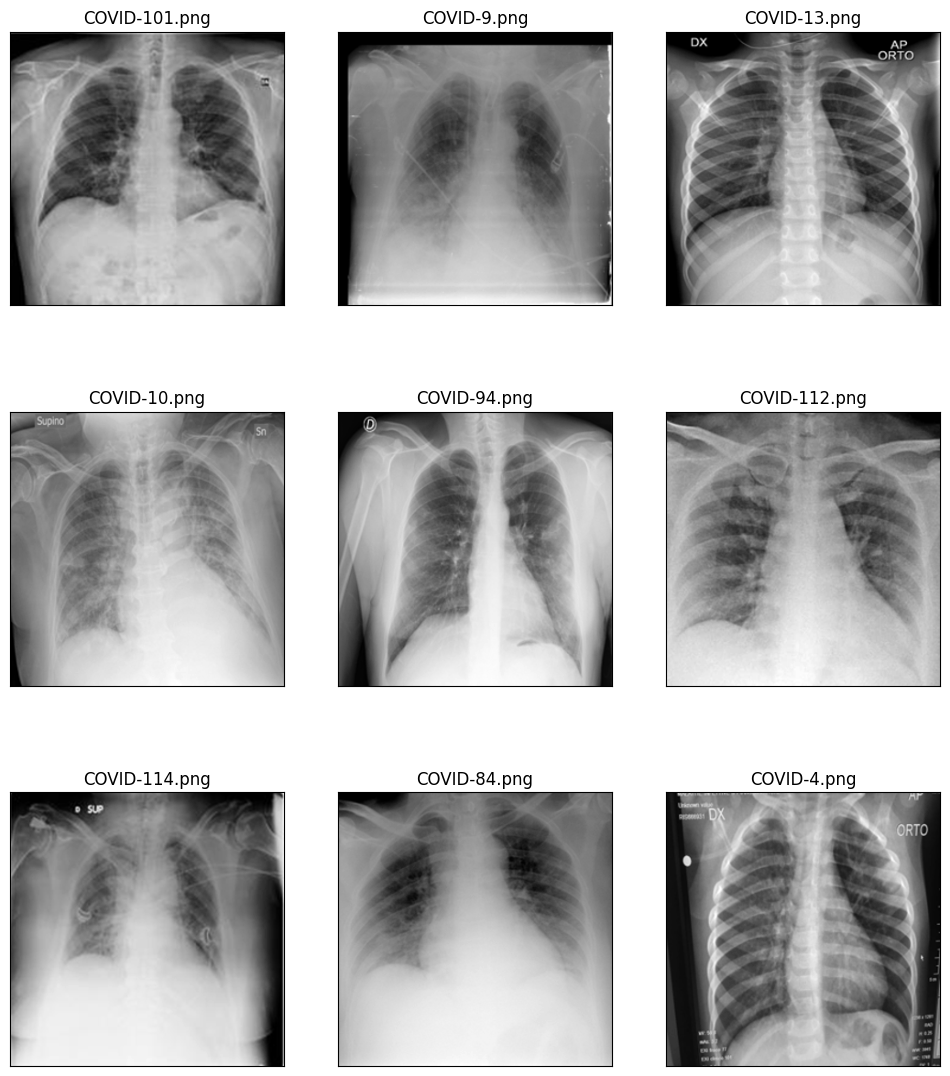

URL: https://github.com/ml-workgroup/covid-19-image-repository/tree/master/png


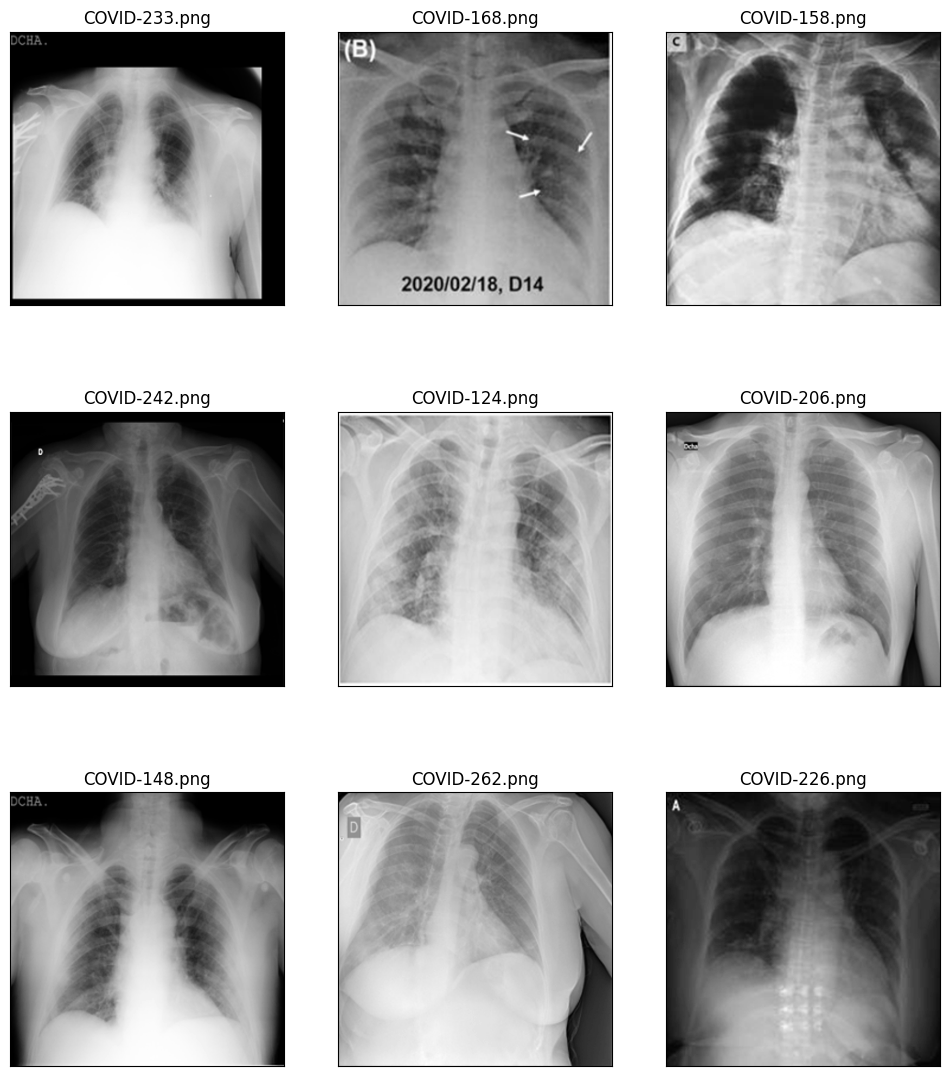

URL: https://eurorad.org


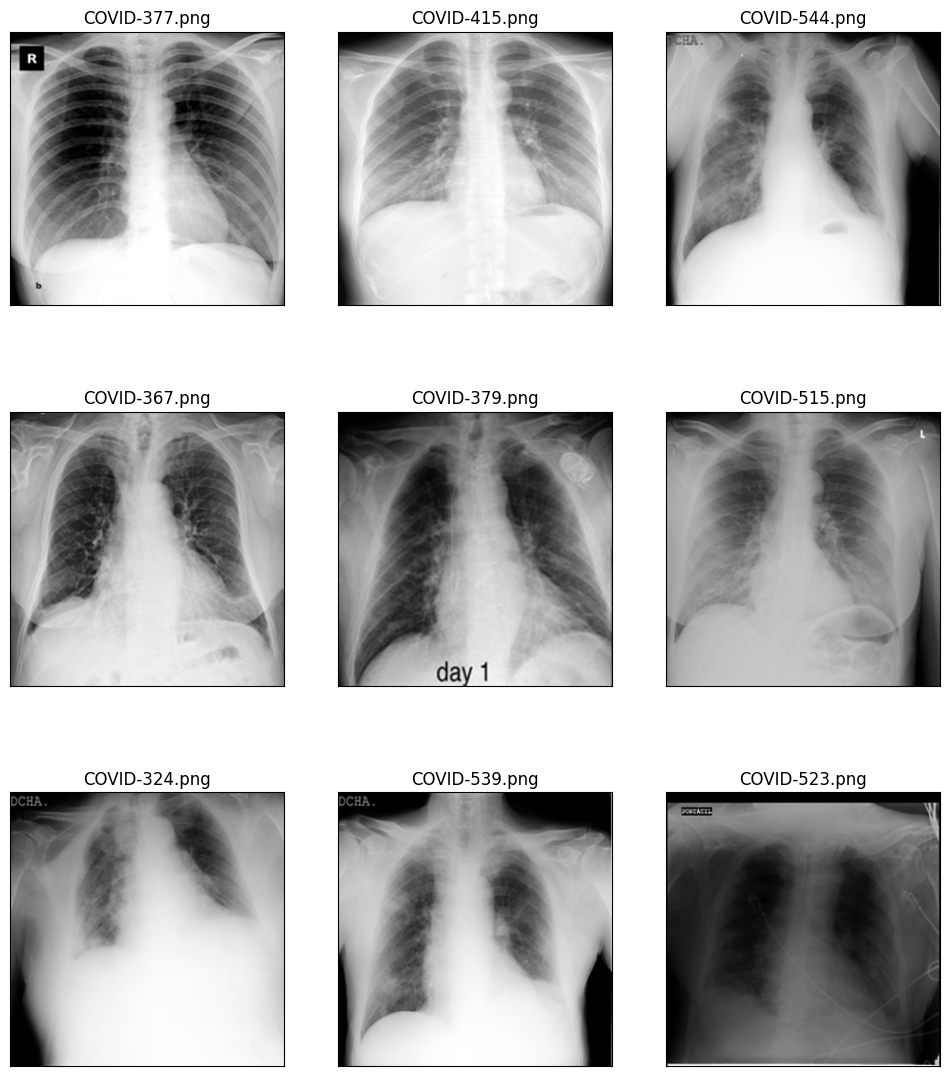

URL: https://github.com/armiro/COVID-CXNet


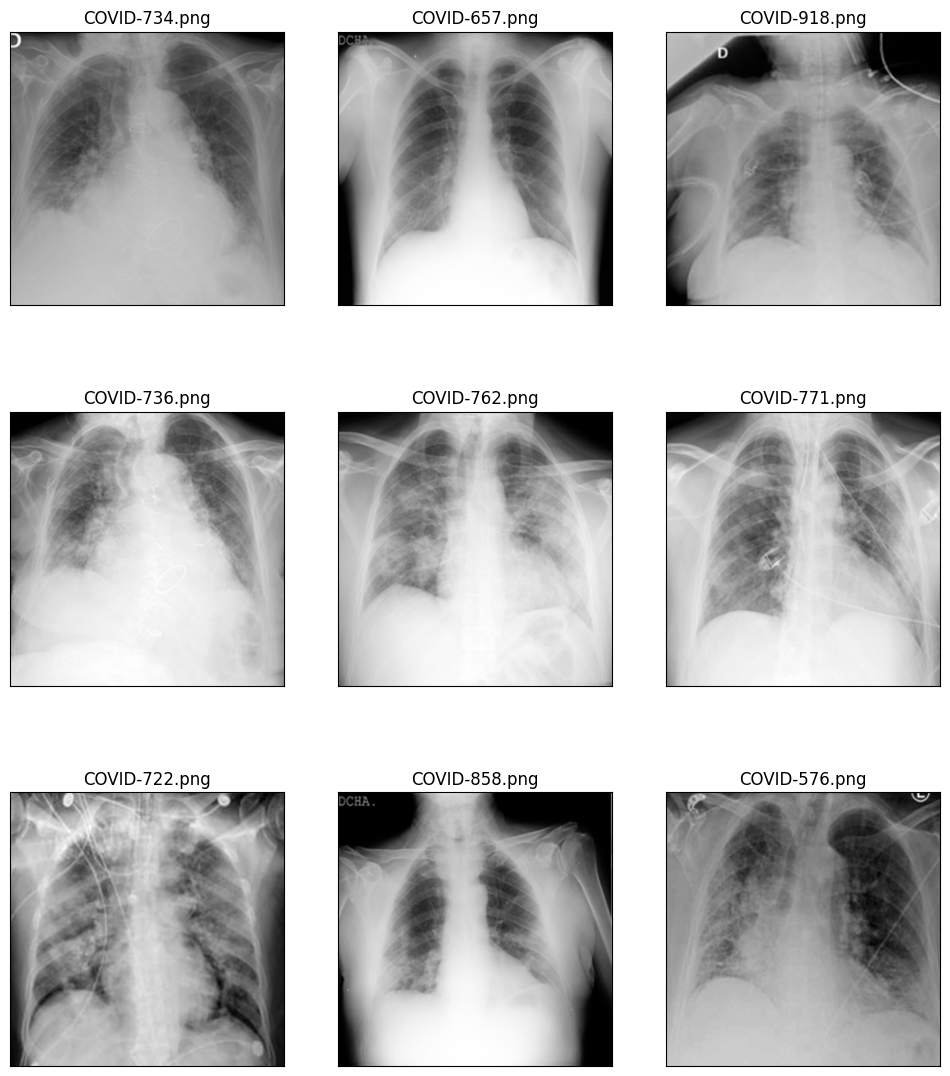

URL: https://github.com/ieee8023/covid-chestxray-dataset


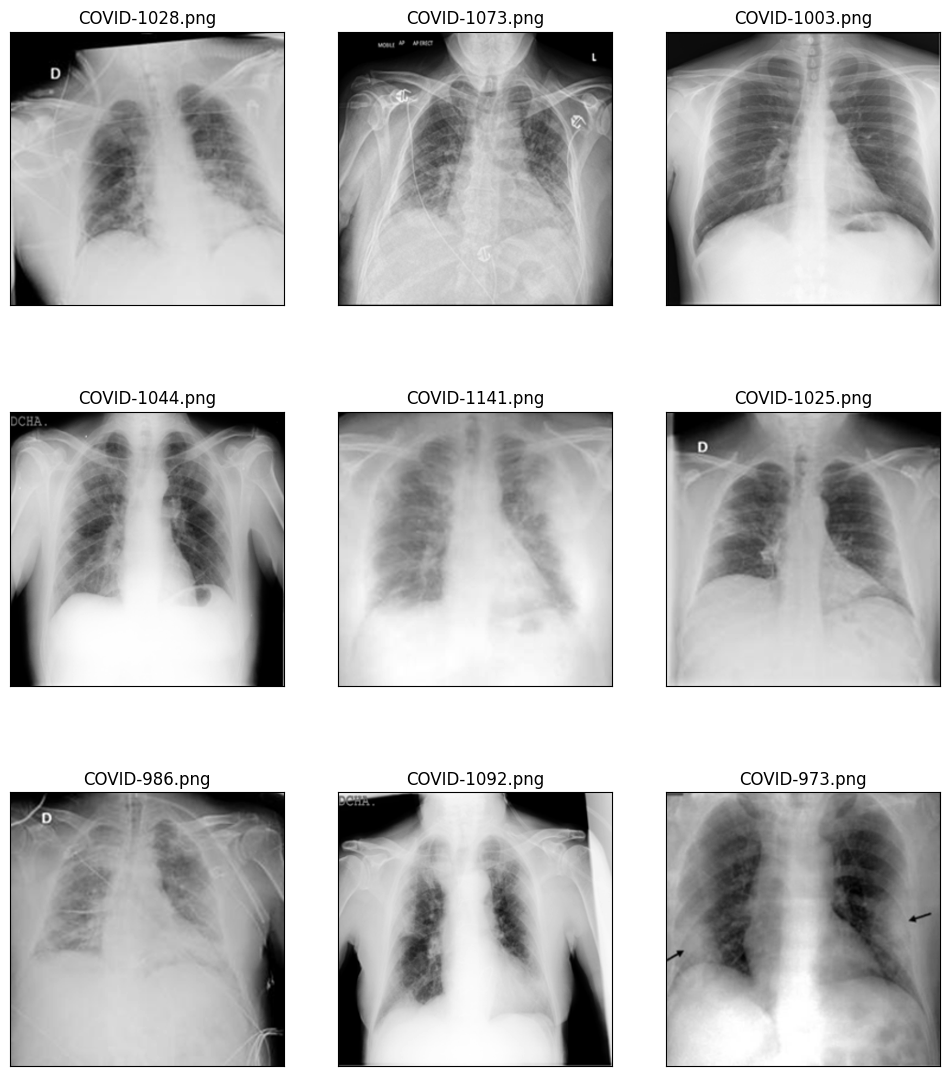

URL: https://bimcv.cipf.es/bimcv-projects/bimcv-covid19/#1590858128006-9e640421-6711


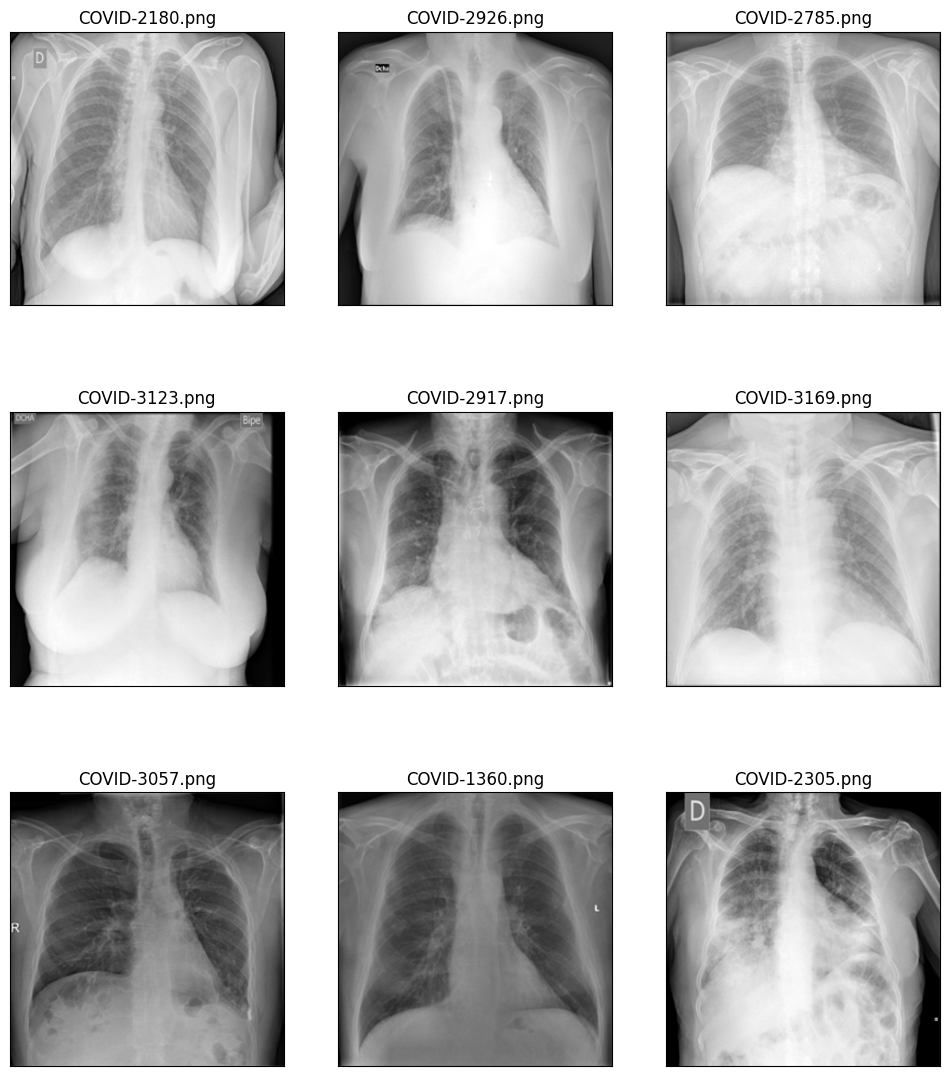

In [22]:
show_sample_images(origin_dictionary_covid, folder_covid)

##### Evaluate 'lung_opacity' images (show some examples of each origin)

In [23]:
excel_path_lung_opacity = os.path.join(folder_path,'Lung_Opacity.metadata.xlsx')
print(excel_path_lung_opacity)
df_lung_opacity = pd.read_excel(excel_path_lung_opacity)
df_lung_opacity.head()

/Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/COVID-19_Radiography_Dataset/Lung_Opacity.metadata.xlsx


,FILE NAME,FORMAT,SIZE,URL
0,Lung_Opacity-1,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
1,Lung_Opacity-2,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
2,Lung_Opacity-3,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
3,Lung_Opacity-4,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
4,Lung_Opacity-5,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...


In [24]:
df_lung_opacity.URL.value_counts()

URL
https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/data    6012
Name: count, dtype: int64

In [25]:
origin_dictionary_lung_opacity = create_origin_dictionary(df_lung_opacity)
for url, file_names in origin_dictionary_lung_opacity.items():
    print('first file from URL:', url, file_names[0])

first file from URL: https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/data Lung_Opacity-1.png


URL: https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/data


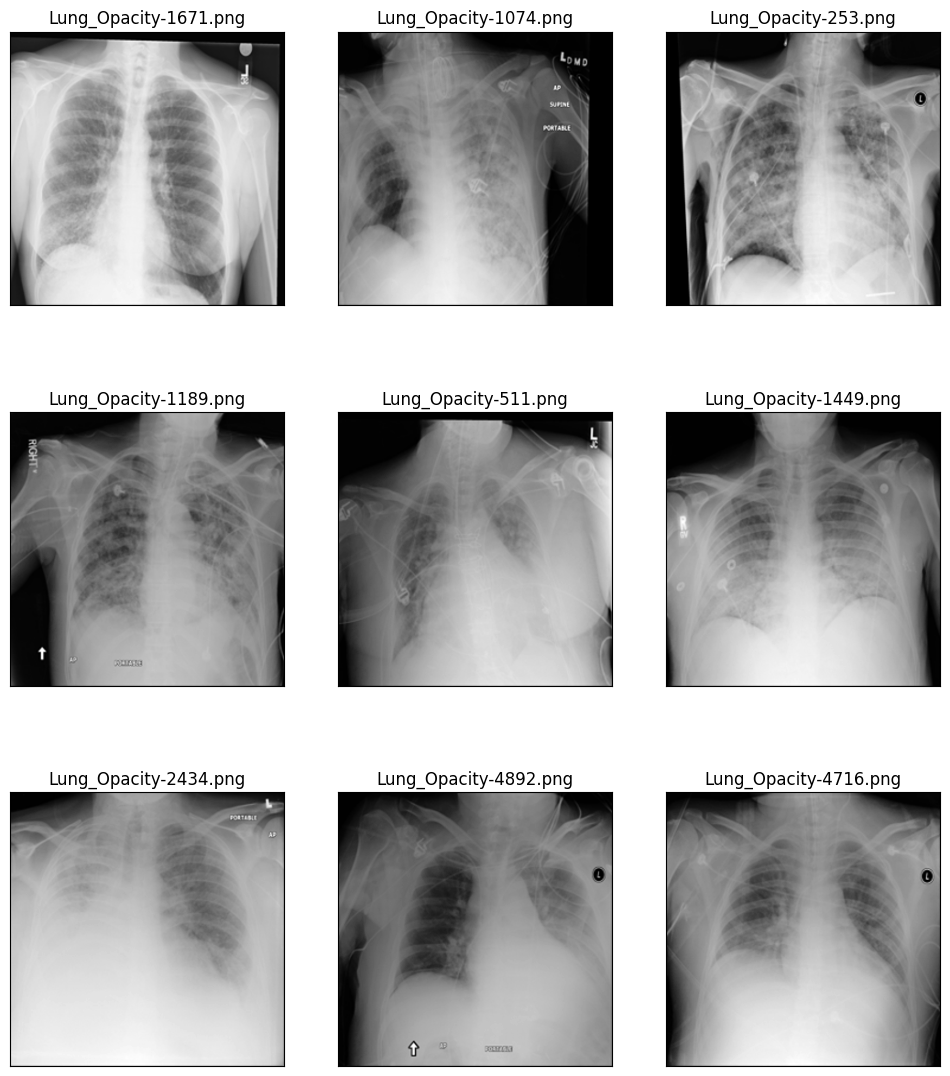

In [26]:
show_sample_images(origin_dictionary_lung_opacity, folder_lung_opacity)

##### Evaluate 'viral_pneumonia' images (show some examples of each origin)

In [27]:
excel_path_viral_pneumonia = os.path.join(folder_path,'Viral Pneumonia.metadata.xlsx')
print(excel_path_viral_pneumonia)
df_viral_pneumonia = pd.read_excel(excel_path_viral_pneumonia)
df_viral_pneumonia.head()

/Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/COVID-19_Radiography_Dataset/Viral Pneumonia.metadata.xlsx


,FILE NAME,FORMAT,SIZE,URL
0,Viral Pneumonia-1,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
1,Viral Pneumonia-2,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
2,Viral Pneumonia-3,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
3,Viral Pneumonia-4,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
4,Viral Pneumonia-5,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...


In [28]:
df_viral_pneumonia.URL.value_counts()

URL
https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia    1345
Name: count, dtype: int64

In [29]:
origin_dictionary_viral_pneumonia = create_origin_dictionary(df_viral_pneumonia)
for url, file_names in origin_dictionary_viral_pneumonia.items():
    print('first file from URL:', url, file_names[0])

first file from URL: https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia Viral Pneumonia-1.png


URL: https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia


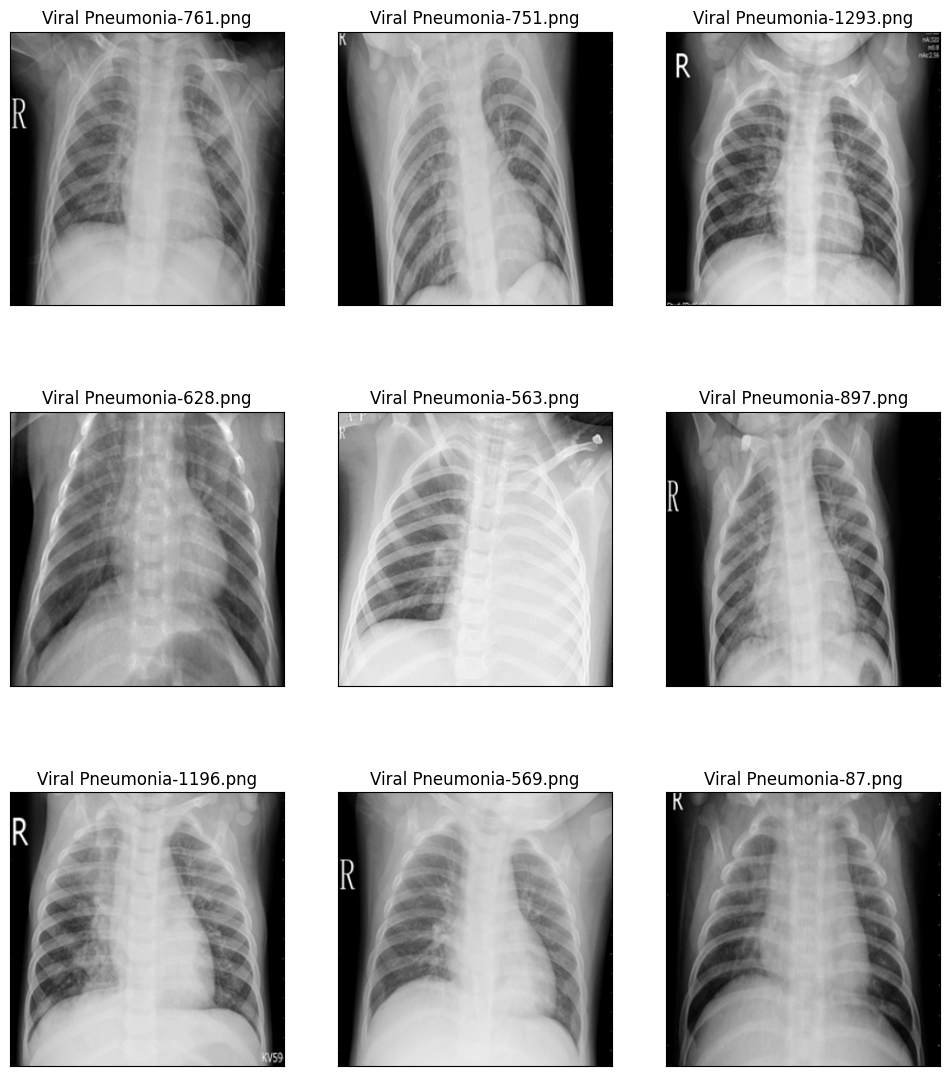

In [30]:
show_sample_images(origin_dictionary_viral_pneumonia, folder_viral_pneumonia)